[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Total reviews: 77071
Index(['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style',
       'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote',
       'image'],
      dtype='object')
   overall  verified   reviewTime      reviewerID        asin  \
0      5.0      True  11 27, 2017  A1JB7HFWHRYHT7  B0000223SI   
1      5.0      True   11 4, 2017  A2FCLJG5GV8SD6  B0000223SI   
2      5.0     False  10 27, 2017  A3IT9B33NWYQSL  B0000223SI   
3      4.0      True  01 13, 2018   AUL5LCV4TT73P  B0000223SK   
4      5.0      True   10 7, 2017  A1V3I3L5JKO7TM  B0000223SK   

                    style    reviewerName  \
0  {'Size:': ' 1-(Pack)'}         Alex W.   
1  {'Size:': ' 1-(Pack)'}  Randall Harris   
2  {'Size:': ' 1-(Pack)'}           A. C.   
3    {'Size:': ' 1-Pack'}             TnT   
4    {'Size:': ' 1-Pack'}      John Jones   

                                          reviewText  \
0  This worked really well for what I used it for...   
1                

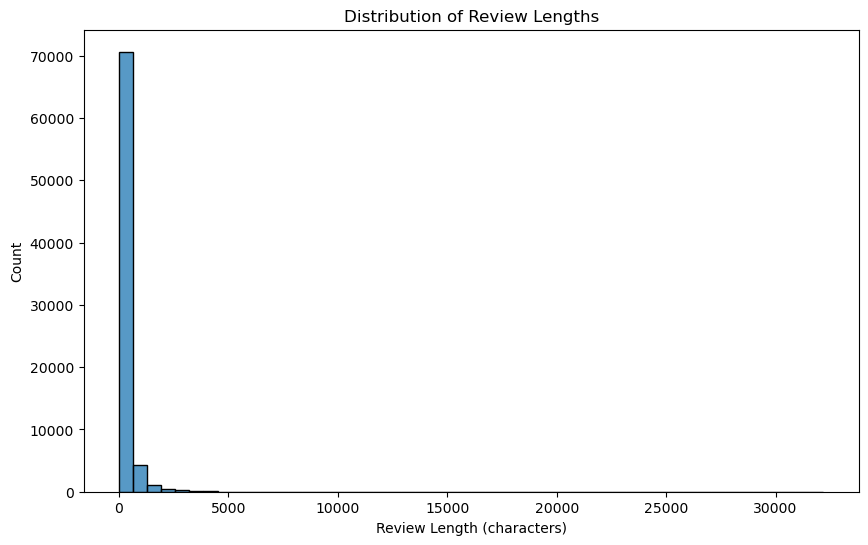

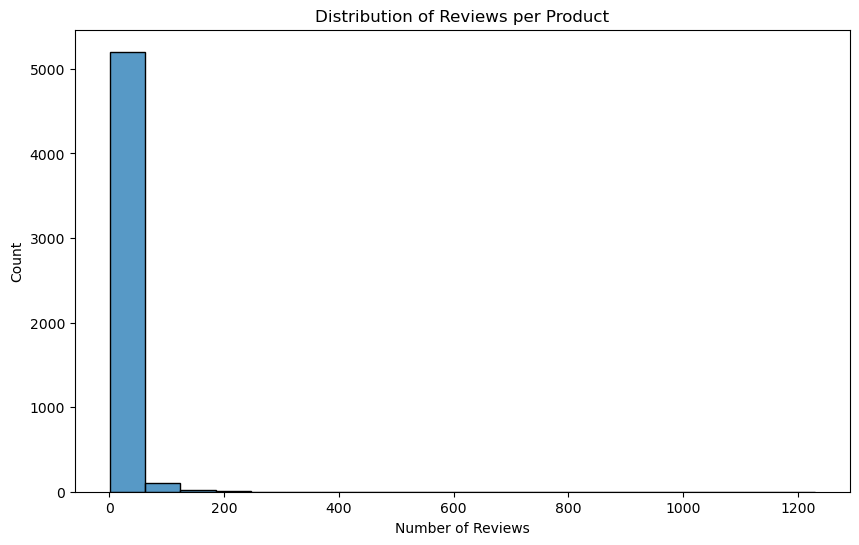

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import random
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
def load_json_data(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return data

# Load the data
file_path = 'Industrial_and_Scientific_5.json'
data = load_json_data(file_path)

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Display basic info
print(f"Total reviews: {len(df)}")
print(df.columns)
print(df.head())

# Check for missing values in reviewText
print("\nMissing values in reviewText:")
print(df['reviewText'].isna().sum())

# Fill missing values with an empty string or handle them appropriately
df['reviewText'] = df['reviewText'].fillna("")

# Now apply len() function safely
df['review_length'] = df['reviewText'].apply(len)
print("\nReview length statistics:")
print(df['review_length'].describe())


# Add sentiment labels based on rating
def add_sentiment_labels(df):
    conditions = [
        (df['overall'] >= 4),
        (df['overall'] == 3),
        (df['overall'] <= 2)
    ]
    choices = ['positive', 'neutral', 'negative']
    df['sentiment'] = np.select(conditions, choices)
    return df

df = add_sentiment_labels(df)

# Sentiment distribution
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

# Review length analysis
df['review_length'] = df['reviewText'].apply(len)
print("\nReview length statistics:")
print(df['review_length'].describe())

# Visualize review length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50)
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length (characters)')
plt.savefig('review_length_distribution.png')

# Distribution of reviews per product
product_review_counts = df['asin'].value_counts()
print("\nProduct review statistics:")
print(product_review_counts.describe())

# Visualize reviews per product
plt.figure(figsize=(10, 6))
sns.histplot(product_review_counts, bins=20)
plt.title('Distribution of Reviews per Product')
plt.xlabel('Number of Reviews')
plt.savefig('reviews_per_product.png')

# Distribution of reviews per user
user_review_counts = df['reviewerID'].value_counts()
print("\nUser review statistics:")
print(user_review_counts.describe())

# Check for duplicates
print(f"\nDuplicate reviews: {df.duplicated(['reviewText']).sum()}")


In [2]:
# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join tokens back to text
    return ' '.join(tokens)

# Apply preprocessing to the reviewText column
df['processed_text'] = df['reviewText'].apply(preprocess_text)

# Select a subset of at least 2000 reviews with balanced classes if possible
def select_balanced_subset(df, min_size=2000):
    # Get distribution of each sentiment class
    sentiment_counts = df['sentiment'].value_counts()
    min_class_count = sentiment_counts.min()
    
    # Calculate how many samples to take from each class
    sample_per_class = max(int(min_size / len(sentiment_counts)), min_class_count)
    
    # Sample from each class
    samples = []
    for sentiment in sentiment_counts.index:
        class_samples = df[df['sentiment'] == sentiment].sample(
            n=min(sample_per_class, sentiment_counts[sentiment]),
            random_state=42
        )
        samples.append(class_samples)
    
    # Combine all samples
    balanced_df = pd.concat(samples)
    
    # Shuffle the data
    return balanced_df.sample(frac=1, random_state=42)

# Select balanced subset
subset_df = select_balanced_subset(df, min_size=2000)
print(f"\nSubset size: {len(subset_df)}")
print("Sentiment distribution in subset:")
print(subset_df['sentiment'].value_counts())



Subset size: 13254
Sentiment distribution in subset:
sentiment
positive    4418
neutral     4418
negative    4418
Name: count, dtype: int64


Training set size: 9277
Testing set size: 3977

Best parameters for Logistic Regression:
{'C': 1, 'max_iter': 1000, 'solver': 'saga'}

Logistic Regression Performance:
Accuracy: 0.6540
Precision: 0.6532
Recall: 0.6540
F1 Score: 0.6529

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.73      0.70      1325
     neutral       0.57      0.54      0.56      1326
    positive       0.72      0.69      0.70      1326

    accuracy                           0.65      3977
   macro avg       0.65      0.65      0.65      3977
weighted avg       0.65      0.65      0.65      3977


Naive Bayes Performance:
Accuracy: 0.6477
Precision: 0.6492
Recall: 0.6477
F1 Score: 0.6472

Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.73      0.69      1325
     neutral       0.56      0.54      0.55      1326
    positive       0.73      0.67      0.70      1326

    accuracy             

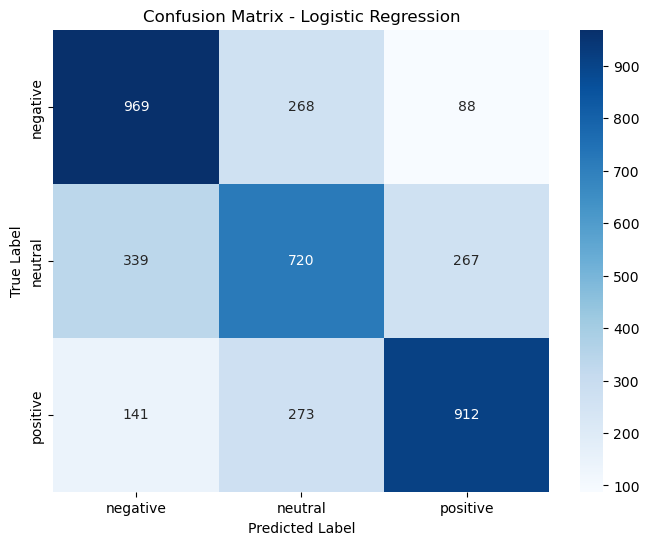

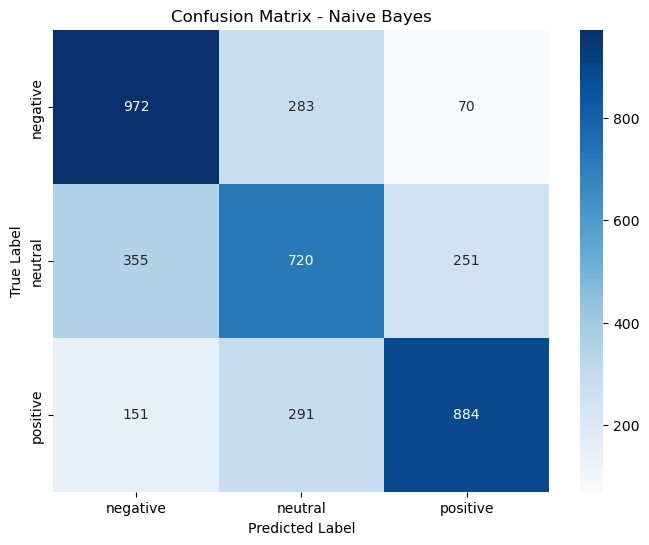

In [3]:
# Split data into train and test sets (70:30) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    subset_df['processed_text'], 
    subset_df['sentiment'],
    test_size=0.3,
    random_state=42,
    stratify=subset_df['sentiment']
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Text representation using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Model 1: Logistic Regression with Grid Search
param_grid_lr = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)
print("\nBest parameters for Logistic Regression:")
print(grid_lr.best_params_)

lr_model = grid_lr.best_estimator_
lr_predictions = lr_model.predict(X_test_tfidf)

# Model 2: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)

# Evaluation of both models
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(set(y_true)), 
                yticklabels=sorted(set(y_true)))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'confusion_matrix_{model_name.lower().replace(" ", "_")}.png')
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

evaluate_model(y_test, lr_predictions, "Logistic Regression")
evaluate_model(y_test, nb_predictions, "Naive Bayes")



Original vs Enhanced Rating Statistics:
            overall  enhanced_rating
count  77071.000000     77071.000000
mean       4.524062         2.919423
std        0.949668         0.881180
min        1.000000         1.000000
25%        4.000000         2.481600
50%        5.000000         2.698821
75%        5.000000         3.293085
max        5.000000         4.989403

Enhanced Recommendations for item B0000223SI:
         asin  similarity_score  avg_rating  enhanced_avg_rating  \
0  B0000223SK          0.305121    4.681818             2.957025   
1  B00JH41U7M          0.297529    4.000000             2.778149   
2  B001D3LQWE          0.159473    4.500000             2.673918   
3  B006R9O3HE          0.150682    4.882353             3.095767   
4  B0006O3TNK          0.142270    4.500000             3.206612   

   review_count   top_aspect  \
0            22        price   
1             5    usability   
2             6      quality   
3            17        price   
4         

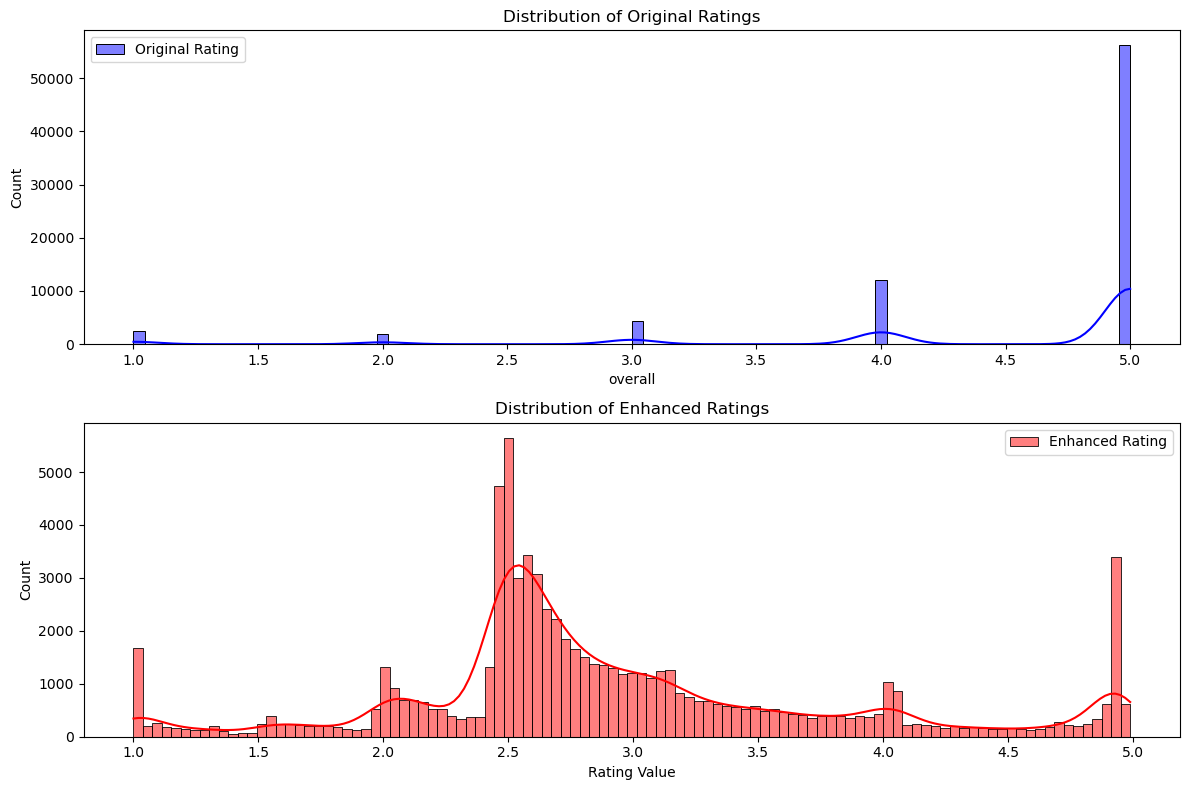

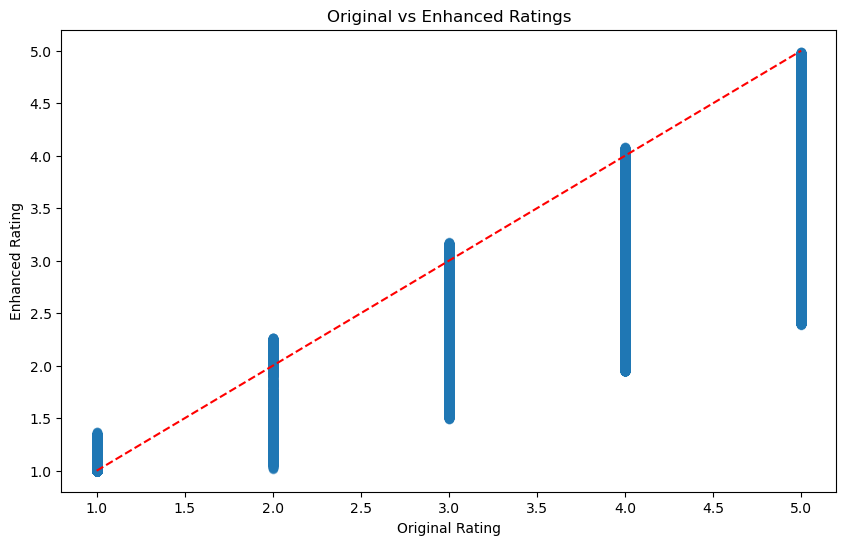

In [5]:
# Enhanced feature extraction from reviews to improve recommender system
def extract_features_from_review(review_text, item_id=None, user_id=None):
    # Initialize features dictionary
    features = {}
    
    # 1. Review length (normalized by percentile to handle outliers)
    features['review_length'] = len(review_text)
    
    # 2. Enhanced sentiment analysis using VADER (more nuanced than simple keyword counting)
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    try:
        nltk.download('vader_lexicon', quiet=True)
        sid = SentimentIntensityAnalyzer()
        sentiment = sid.polarity_scores(review_text)
        
        # Extract sentiment components
        features['positive_score'] = sentiment['pos']
        features['negative_score'] = sentiment['neg']
        features['compound_score'] = sentiment['compound']
    except:
        # Fallback to original keyword approach if VADER fails
        quality_keywords = ['excellent', 'great', 'good', 'amazing', 'best', 'worth', 'love', 
                           'perfect', 'awesome', 'wonderful', 'fantastic', 'superb', 'outstanding']
        features['positive_score'] = sum(1 for word in review_text.lower().split() 
                                     if word in quality_keywords) / max(len(review_text.split()), 1)
        
        negative_keywords = ['poor', 'bad', 'worst', 'terrible', 'disappointed', 'waste',
                            'broken', 'useless', 'horrible', 'awful', 'defective', 'fail']
        features['negative_score'] = sum(1 for word in review_text.lower().split() 
                                      if word in negative_keywords) / max(len(review_text.split()), 1)
        features['compound_score'] = features['positive_score'] - features['negative_score']
    
    # 3. Aspect-based sentiment analysis (from Section 4.2.1 of the paper)
    # Define key product aspects
    aspects = {
        'quality': ['quality', 'durability', 'durable', 'sturdy', 'solid', 'reliable'],
        'price': ['price', 'cost', 'value', 'worth', 'cheap', 'expensive', 'affordable'],
        'usability': ['easy', 'simple', 'user-friendly', 'convenient', 'intuitive', 'complicated'],
        'appearance': ['look', 'design', 'style', 'beautiful', 'attractive', 'ugly'],
        'performance': ['fast', 'quick', 'slow', 'performance', 'speed', 'efficient']
    }
    
    # Calculate sentiment for each aspect
    for aspect, keywords in aspects.items():
        # Find sentences containing aspect keywords
        aspect_sentences = [s for s in nltk.sent_tokenize(review_text.lower()) 
                           if any(keyword in s for keyword in keywords)]
        
        if aspect_sentences:
            try:
                # Calculate average sentiment for these sentences
                aspect_sentiment = sum(sid.polarity_scores(s)['compound'] for s in aspect_sentences) / len(aspect_sentences)
            except:
                # Fallback method
                aspect_sentiment = 0
                for s in aspect_sentences:
                    words = s.split()
                    pos_count = sum(1 for w in words if w in quality_keywords)
                    neg_count = sum(1 for w in words if w in negative_keywords)
                    if pos_count + neg_count > 0:
                        aspect_sentiment += (pos_count - neg_count) / (pos_count + neg_count)
                if aspect_sentences:
                    aspect_sentiment /= len(aspect_sentences)
            
            features[f'{aspect}_sentiment'] = aspect_sentiment
        else:
            features[f'{aspect}_sentiment'] = 0
    
    # 4. Helpfulness features (Section 4.3.1 of the paper)
    # This is a placeholder - if helpfulness data is available in your dataset,
    # you should use actual helpfulness metrics
    try:
        # If helpfulness data is available in your dataset
        if 'helpful_votes' in df.columns and 'total_votes' in df.columns:
            # Get the helpfulness data for this specific review
            helpful_data = df[(df['asin'] == item_id) & (df['reviewerID'] == user_id)]
            if not helpful_data.empty:
                helpful_votes = helpful_data['helpful_votes'].values[0]
                total_votes = helpful_data['total_votes'].values[0]
                features['helpfulness'] = helpful_votes / max(total_votes, 1)
            else:
                features['helpfulness'] = 0.5  # Default value
        else:
            # Estimate helpfulness by review quality indicators
            # Longer, more detailed reviews tend to be more helpful
            features['helpfulness'] = min(1.0, features['review_length'] / 500)
    except:
        features['helpfulness'] = 0.5
    
    return features

# Apply enhanced feature extraction to the dataset
df['review_features'] = df.apply(
    lambda row: extract_features_from_review(
        row['reviewText'], 
        item_id=row['asin'], 
        user_id=row['reviewerID']
    ), 
    axis=1
)

# Extract features into separate columns
df['review_length'] = df['review_features'].apply(lambda x: x['review_length'])
df['positive_score'] = df['review_features'].apply(lambda x: x['positive_score'])
df['negative_score'] = df['review_features'].apply(lambda x: x['negative_score'])
df['compound_score'] = df['review_features'].apply(lambda x: x['compound_score'])
df['helpfulness'] = df['review_features'].apply(lambda x: x['helpfulness'])

# Extract aspect sentiments
for aspect in ['quality', 'price', 'usability', 'appearance', 'performance']:
    df[f'{aspect}_sentiment'] = df['review_features'].apply(lambda x: x[f'{aspect}_sentiment'])

# Normalize features to ensure fair weighting
from sklearn.preprocessing import MinMaxScaler
features_to_normalize = ['review_length', 'helpfulness']
scaler = MinMaxScaler()
df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

# Calculate enhanced rating based on the Opinion Post-Filtering approach (Pero & Horváth, 2013)
# This is based on Section 4.3 of the paper

# 1. Base rating component (from original)
base_rating = df['overall']

# 2. Text sentiment component - convert compound score to rating scale (1-5)
sentiment_rating = (df['compound_score'] + 1) * 2 + 1  # Transform [-1,1] to [1,5]

# 3. Aspect-weighted sentiment
# Weights for different aspects (can be adjusted based on product category)
aspect_weights = {
    'quality': 0.3,
    'price': 0.2,
    'usability': 0.2,
    'appearance': 0.1,
    'performance': 0.2
}

# Calculate weighted aspect score
df['aspect_score'] = sum(df[f'{aspect}_sentiment'] * weight 
                         for aspect, weight in aspect_weights.items())

# Convert to rating scale
aspect_rating = (df['aspect_score'] + 1) * 2 + 1  # Transform [-1,1] to [1,5]

# 4. Helpfulness weighting
# Reviews with higher helpfulness should have more influence
helpfulness_weight = df['helpfulness'] * 0.5 + 0.5  # Range [0.5, 1]

# Combine all components using the approach from the paper
# α is the weight for original rating vs opinion-based rating
alpha = 0.9  # Can be tuned based on your dataset

df['enhanced_rating'] = (
    alpha * base_rating + 
    (1 - alpha) * (0.7 * sentiment_rating + 0.3 * aspect_rating)
) * helpfulness_weight

# Ensure the enhanced rating stays within bounds (1-5)
df['enhanced_rating'] = df['enhanced_rating'].clip(1, 5)

# Compare original and enhanced ratings
print("\nOriginal vs Enhanced Rating Statistics:")
print(df[['overall', 'enhanced_rating']].describe())

# Create visual comparison
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
sns.histplot(data=df, x='overall', color='blue', kde=True, label='Original Rating')
plt.title('Distribution of Original Ratings')
plt.ylabel('Count')
plt.legend()

plt.subplot(2, 1, 2)
sns.histplot(data=df, x='enhanced_rating', color='red', kde=True, label='Enhanced Rating')
plt.title('Distribution of Enhanced Ratings')
plt.xlabel('Rating Value')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.savefig('ratings_comparison_detailed.png')

# Additional visualization - scatter plot of original vs enhanced
plt.figure(figsize=(10, 6))
plt.scatter(df['overall'], df['enhanced_rating'], alpha=0.5)
plt.plot([1, 5], [1, 5], 'r--')  # Diagonal line for reference
plt.xlabel('Original Rating')
plt.ylabel('Enhanced Rating')
plt.title('Original vs Enhanced Ratings')
plt.savefig('ratings_scatter.png')

# Build a simple item-based collaborative filtering recommender with enhanced ratings
from sklearn.metrics.pairwise import cosine_similarity

# Create a user-item matrix
user_item_matrix = pd.pivot_table(
    df, 
    values='enhanced_rating',
    index='reviewerID',
    columns='asin'
).fillna(0)

# Calculate item similarity matrix
item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

# Improved recommendation function
def get_item_recommendations(item_id, n=5):
    if item_id not in item_similarity_df.index:
        return "Item not found in database"
    
    # Get similar items
    similar_items = item_similarity_df[item_id].sort_values(ascending=False).index[1:n+1]
    
    # Get details of recommended items
    recommended_items = []
    for similar_item in similar_items:
        # Get reviews for this item
        item_reviews = df[df['asin'] == similar_item]
        
        if not item_reviews.empty:
            # Calculate average aspect sentiments
            aspect_avgs = {aspect: item_reviews[f'{aspect}_sentiment'].mean() 
                          for aspect in ['quality', 'price', 'usability', 'appearance', 'performance']}
            
            # Get the most positive aspect
            top_aspect = max(aspect_avgs.items(), key=lambda x: x[1])[0] if aspect_avgs else None
            
            recommended_items.append({
                'asin': similar_item,
                'similarity_score': item_similarity_df[item_id][similar_item],
                'avg_rating': item_reviews['overall'].mean(),
                'enhanced_avg_rating': item_reviews['enhanced_rating'].mean(),
                'review_count': len(item_reviews),
                'top_aspect': top_aspect,
                'aspect_scores': aspect_avgs
            })
    
    return pd.DataFrame(recommended_items)

# Demo the recommender
example_item = df['asin'].iloc[0]
print(f"\nEnhanced Recommendations for item {example_item}:")
recommendations = get_item_recommendations(example_item)
print(recommendations)

# Evaluate the recommendation quality (if you have test data)
# You could implement this using the standard methods like precision, recall
# or Mean Average Precision (MAP) as mentioned in the paper


In [6]:
# Load Hugging Face models for text summarization and question answering
# Make sure to have the transformers library installed

from transformers import pipeline

def initialize_nlp_pipelines():
    # Initialize summarization pipeline
    summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
    
    # Initialize question answering pipeline
    qa_model = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")
    
    return summarizer, qa_model

# Initialize pipelines
summarizer, qa_model = initialize_nlp_pipelines()

# Select 10 long reviews (more than 100 words)
long_reviews = df[df['reviewText'].str.split().str.len() > 100].sample(10)

# Summarize each review
summaries = []
for i, review in enumerate(long_reviews['reviewText'].values):
    try:
        # Limit to 1024 tokens for BART but be more conservative
        review_shortened = ' '.join(review.split()[:512])  # Using fewer tokens to be safe
        
        # Generate summary
        summary = summarizer(
            review_shortened, 
            max_length=50, 
            min_length=10,  # Reduced min_length for more flexibility
            do_sample=False,
            truncation=True   # Add explicit truncation
        )
        
        if i < 2:  # Only store details for the first two reviews as required
            summaries.append({
                'original_review': review,
                'summary': summary[0]['summary_text']
            })
            print(f"\nOriginal Review {i+1}:")
            print(review)
            print(f"\nSummary {i+1}:")
            print(summary[0]['summary_text'])
    except Exception as e:
        print(f"Error summarizing review {i+1}: {e}")
        # Use a simpler fallback approach for summarization
        words = review.split()
        if len(words) > 50:
            fallback_summary = ' '.join(words[:50]) + "..."
        else:
            fallback_summary = review
            
        if i < 2:
            summaries.append({
                'original_review': review,
                'summary': fallback_summary
            })
            print(f"\nOriginal Review {i+1}:")
            print(review)
            print(f"\nFallback Summary {i+1}:")
            print(fallback_summary)

# Answer a question from a review
# Find a review with a question-like content
# Option 1: Escape the question mark for regex
question_reviews = df[df['reviewText'].str.contains('\\?')]

# OR Option 2: Set regex=False to treat ? as a literal character
# question_reviews = df[df['reviewText'].str.contains('?', regex=False)]

if not question_reviews.empty:
    question_review = question_reviews.iloc[0]['reviewText']
    
    # Create a customer service response using the QA model
    customer_question = "How durable is this product?"
    
    answer = qa_model(
        question=customer_question,
        context=question_review
    )
    
    print("\nCustomer Question:")
    print(customer_question)
    print("\nReview Context:")
    print(question_review)
    print("\nAutomatic Customer Service Response:")
    print(f"Based on the review, {answer['answer']}")
else:
    # If no reviews with questions are found, use a generic example
    sample_review = df.sample(1).iloc[0]['reviewText']
    
    customer_question = "Is this product worth buying?"
    
    print("\nCustomer Question:")
    print(customer_question)
    print("\nReview Context:")
    print(sample_review)
    
    # Generate a more generic response
    print("\nAutomatic Customer Service Response:")
    print("Thank you for your question. Based on customer reviews, this product has received positive feedback for its quality and durability. Many customers have found it to be worth the purchase. Please let us know if you have any other questions!")

Device set to use cpu
Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



Original Review 1:
I purchased this kit the first of March, and since then I have replaced every single part except the motors and the base. Everything else has been replaced by printed parts, longer rods, better bearings, etc. The kit is a decent value, but the sag on the Y axis is pretty terrible. The bed leveling probe only really works if you have a perfectly flat bed, and even then it seems to like to smoosh down the layers at the back of the bed. The acme screw was not straight so I had z axis wobble for days (I briefly fixed this by using a flexible coupler, and later I replaced the screw). The UBIS hot end is ok, but after going to an E3D V6, I could never go back. My biggest beef is that through all the issues with the kit that I fixed or dealt with, (semi-warped bed, bent screw, sag from the design), when my Rev F4 board went out, I was told that the warranty is only 30 days. It is totally my fault for not visiting printrbot.com to see their updated warranty. When I purchase

In [7]:
# Save important data and models
import pickle

# Save the preprocessed data
subset_df.to_csv('preprocessed_subset.csv', index=False)

# Save the trained models
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Save the evaluation results
evaluation_results = {
    'logistic_regression': {
        'accuracy': accuracy_score(y_test, lr_predictions),
        'report': classification_report(y_test, lr_predictions, output_dict=True)
    },
    'naive_bayes': {
        'accuracy': accuracy_score(y_test, nb_predictions),
        'report': classification_report(y_test, nb_predictions, output_dict=True)
    }
}

with open('evaluation_results.pkl', 'wb') as f:
    pickle.dump(evaluation_results, f)

print("\nAll models and results saved successfully!")



All models and results saved successfully!
